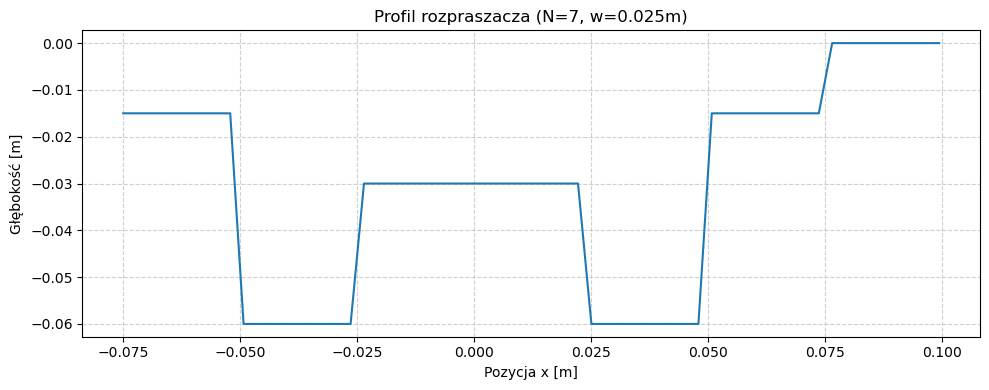

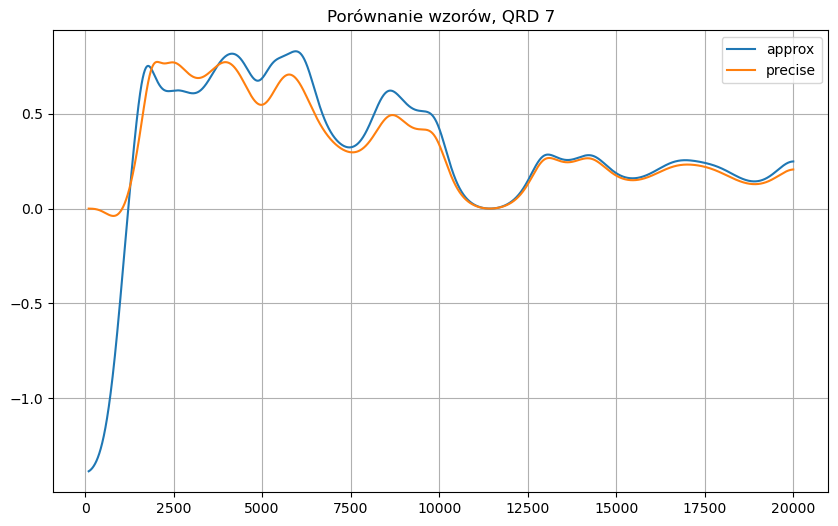

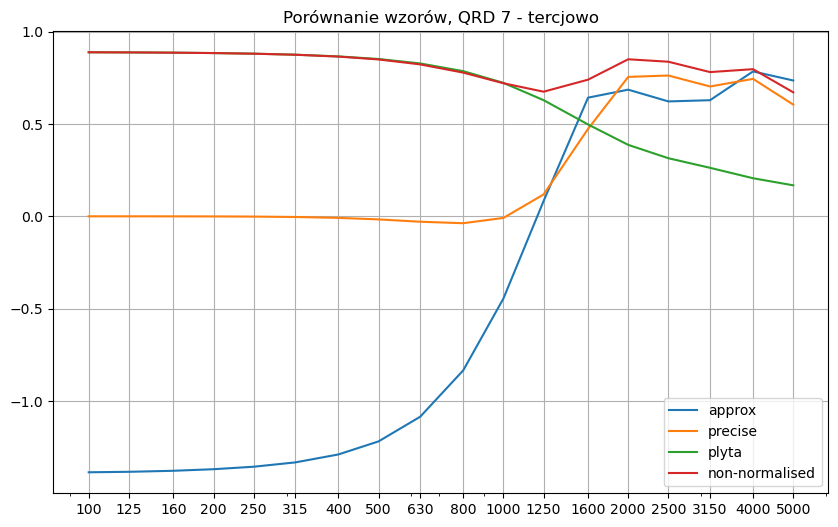

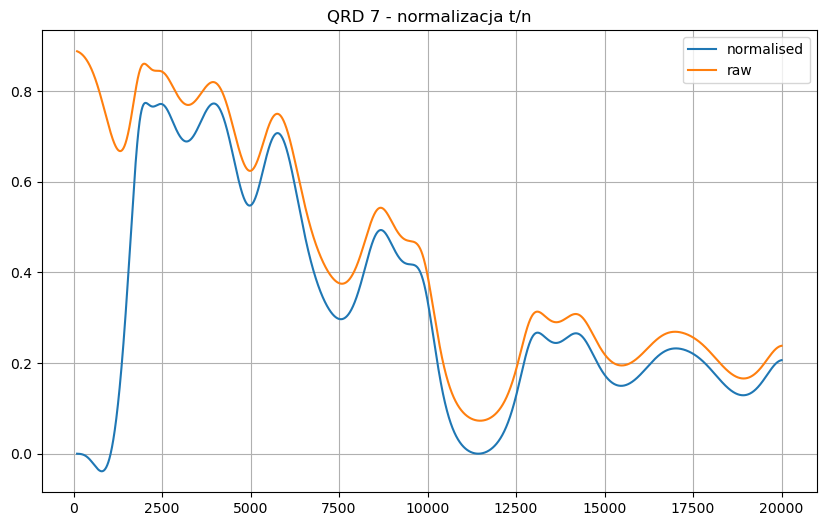

------------------------------
Indeks   | sn   | Głębokość [m]
0        | 1    | 0.0150
1        | 4    | 0.0600
2        | 2    | 0.0300
3        | 2    | 0.0300
4        | 4    | 0.0600
5        | 1    | 0.0150
6        | 0    | 0.0000

szer. studzienki = 0.025 m, wymiary calego rozpraszacza = 0.1750 m x 0.6000 m
Zakres częstotliwości: 1633.33 Hz - 6860.00 Hz


In [7]:
import numpy as np
import matplotlib.pyplot as plt



### ZMIENNE GLOBALNE / WARUNKI POMIARU
_c = 343 #m/s
_fmaxHz = 20000 #Hz
_l6 = _c/_fmaxHz/6
_r0 = 10 #m Odległość źródła dźwięku od próbki
_r = 5 #m Odległość mikrofonów od próbki
_freqs = np.arange(100, _fmaxHz+0.01, 2) #Częstotliwość
_phi =  np.arange(-1*np.pi/2, np.pi/2+0.01, np.pi/180) # Kąt analizy odbicia fali dźwiękowej


_b = 0.3 #m Połowa szerokości rozpraszacza
_w = 0.025# m Szerokość jednej studzienki
_hmax = 0.06 #m
_N = 7 #Długość ciągu pseudolosowego

def qrd(n):
    n_ids = np.arange(0, n, 1) # Numeracja studzienek rozpraszazcza  
    return (n_ids+1)**2%n #Wyrazy ciągu pseudolosowego

sn = qrd(_N)


class Diffuser:
    def __init__(self, sn, max_depth, w, b=_b, c=_c, l6=_l6):
        """
        Parametry:
        :param sn: array - sekwencja bazowa rozpraszacza (np. z reszt kwadratowych)
        :param max_depth: float - maksymalna głębokość konstrukcji (_hmax)
        :param w: float - szerokość pojedynczej studzienki (_w)
        :param b: float - połowa szerokości rozpraszacza
        :param c: float - prędkość dźwięku (domyślnie 343 m/s)
        :param l6: float - krok próbkowania wzdłuż osi X (rozdzielczość wykresu)
        """
        self.sn = np.array(sn)
        self._N = len(self.sn)
        self._w = w
        self._hmax = max_depth
        self._c = c
        self.b = b
        

        self.xs = None #wektor siatki
        self.hx = None #glebokosci w punkcie siatki
        
        
        # Rozdzielczość osi x (jeśli nie podano, przyjmij lambda/6 dla gornej granicy pasma slyszalnego
        self.l6 = l6 if l6 is not None else c/20000/6

        # Obliczenia głębokości (hn)
        depth_factor = self._hmax / np.max(self.sn)
        self.hn = self.sn * depth_factor
        self.jestem_plyta = (max_depth == 0)

        # Generowanie pozycji wzdłuż osi x (xs)
        start = -(self._N - 1) / 2 * self._w
        stop = (self._N + 1) / 2 * self._w
        self.xs = np.arange(start, stop, self.l6)

        # Mapowanie głębokości na gęstą siatkę x (hx)
        hx = []
        for x in self.xs:
            x = x+ np.abs(self.xs[0])
            hx.append(self.hn[int(np.floor(x/self._w))])
        self.hx = np.array(hx)

        if(not self.jestem_plyta):
            # Zakres częstotliwości skutecznych
            self.lmin = 2 * self._w
            self.lmax = 2 * self._N * self._hmax / np.max(self.sn)
            self.freqmin = self._c / self.lmax
            self.freqmax = self._c / self.lmin
   

    def __str__(self):
        total_width = self._N * self._w
        output = "-" * 30 + "\n"
        output += f"{'Indeks':<8} | {'sn':<4} | {'Głębokość [m]':<12}\n"
        
        
        for i in range(self._N):
            output += f"{i:<8} | {self.sn[i]:<4} | {self.hn[i]:.4f}\n"
        
        if(not self.jestem_plyta):
            output += f"\nszer. studzienki = {self._w} m, wymiary calego rozpraszacza = {total_width:.4f} m x {2*self.b:.4f} m\n"
            output += f"Zakres częstotliwości: {self.freqmin:.2f} Hz - {self.freqmax:.2f} Hz"
        
        return output

    def plot(self):
        """Generuje wykres profilu rozpraszacza."""
        plt.figure(figsize=(10, 4))
        plt.plot(self.xs, 0 - self.hx)#, drawstyle='steps-post')   #- steps-post lepiej oddaje skokowy charakter studzienek
        # plt.fill_between(self.xs, 0 - self.hx, 0, alpha=0.3)
        if(self.jestem_plyta):
            plt.title(f"Płyta, (N={self._N}, w={self._w}m) ")
        else:
            plt.title(f"Profil rozpraszacza (N={self._N}, w={self._w}m)")
        
        plt.xlabel("Pozycja x [m]")
        plt.ylabel("Głębokość [m]")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()


def k_num(f):
    lc = _c/f
    return 2*np.pi/lc

def R(f, d: Diffuser):
    return np.exp(-1j * 2 * np.outer(k_num(f), d.hx))

def pressures(dif: Diffuser, formula = 'b'):

    Rs = R(_freqs, dif) #matrix (f, hx)
    
    Mh = dif.hx[None,:,None]
    Mk, Mx, Mphi = np.meshgrid(k_num(_freqs), dif.xs, _phi, indexing='ij', sparse=True)

    #Dims: (freqs, xs, phis)
    #Rs_3d:(:   , hx(xs), :)
    Rs_3d = Rs[:,:,None]
    

    if(formula == 'a'):
        #approx formula chosen
        ps = np.sum(np.abs(Rs_3d) * np.exp(1j*(2*Mk*Mh - Mx*Mk*np.sin(Mphi))), axis = 1)
    elif(formula == 'b'):
        integral =  np.sum(Rs_3d * np.exp(1j * Mk * Mx * np.sin(Mphi))*dif.l6, axis = 1)
        integral = integral[:,None,:]
        ps = -1j * Mk/8/np.pi**2 * np.exp(-1j * Mk * (_r + _r0)) * np.sinc(Mk*dif.b/_r/np.pi)*(np.cos(Mphi) + 1) * integral   #TODO CZY sinc jest normalizowany czy zwykły? Chat mi to debuguguje usilnie
        ps = np.squeeze(ps, axis=1)
    else:
        print("ERROR: pick correct formula. 'a' for approx, 'b' for precise")
    #Dim ps : (freqs, thetas)
    return ps


def d_coeff(dif: Diffuser, formula = 'b'):
    ps = pressures(dif, formula)

    num_thetas = ps.shape[1]
    ps_sq = np.abs(ps)**2
    ps_sqsq = ps_sq**2
    thetas_sq_sum = np.sum(ps_sq, axis = 1)
    thetas_sqsq_sum = np.sum(ps_sqsq, axis = 1)
    return (thetas_sq_sum**2 - thetas_sqsq_sum) / (num_thetas - 1) / thetas_sqsq_sum

def d_coeff_normalised(dif: Diffuser, formula = 'b'):
    d = d_coeff(dif, formula)

    plyta = Diffuser(dif.sn, 0, dif._w)  #TODO mona zoptymalizować - wiele normalizowanych obliczeń w skrypcie wymaga tylko jednokrotnego policzenia płyty - przechować globalnie?
    d_0 =  d_coeff(plyta, formula)
    return (d - d_0) / (1-d_0), d

fc_tercje = np.array([100, 125, 160, 200, 250, 315, 400, 500, 630, 800, 
                      1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000])


def to_thirds(x):
    alfa_tercje = []
    for fc in fc_tercje:
        fd = fc * (2 ** (-1/6))
        fg = fc * (2 ** (1/6))
        
        mask = (_freqs >= fd) & (_freqs <= fg)
   
        alfa_avg = np.mean(x[mask])
        alfa_tercje.append(alfa_avg)

    return np.array(alfa_tercje)

#################################################
################################################
#################################################
################################################
#################################################
################################################
#################################################
################################################


myDif = Diffuser(sn,_hmax, _w)
plyta = Diffuser(sn, 0, _w) 
myDif.plot()

a, a_raw = d_coeff_normalised(myDif, 'a')
b, b_raw = d_coeff_normalised(myDif, 'b')
dp = d_coeff(plyta, 'b')

plt.figure(figsize=(10,6))
plt.title("Porównanie wzorów, QRD 7")
plt.plot(_freqs, a, label = "approx")
plt.plot(_freqs, b,label = "precise")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.title("Porównanie wzorów, QRD 7 - tercjowo")
plt.semilogx(fc_tercje, to_thirds(a), label = "approx")
plt.semilogx(fc_tercje, to_thirds(b),label = "precise")
plt.semilogx(fc_tercje, to_thirds(dp),label = "plyta")
plt.semilogx(fc_tercje, to_thirds(b_raw),label = "non-normalised")
plt.legend()
plt.xticks(fc_tercje,fc_tercje)
plt.grid()
plt.show()

plt.figure(figsize=(10,6))
plt.title("QRD 7 - normalizacja t/n")
plt.plot(_freqs, b, label = "normalised")
plt.plot(_freqs, b_raw,label = "raw")
plt.legend()
plt.grid()
plt.show()



print(myDif)
